In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# import xarray as xr
# import geopandas as gpd
# import rioxarray
# import xcdat as xc

In [2]:
df = pd.read_csv(
    "Data/Q_Pisuerga.txt",
    sep=";",
    skipinitialspace=True,
    na_values=["-999.000", "-999"],
    skiprows=36,
    encoding="latin-1"
)
df.describe()

,Value
count,18078.000000
mean,61.361974
std,85.712088
min,0.000000
25%,22.700000
50%,34.990000
75%,65.350000
max,2060.000000


In [3]:
Q_Pis = df.drop(columns=df.columns[1])
Q_Pis.columns = ["Date", "Q"]
Q_Pis["Date"] = pd.to_datetime(Q_Pis["Date"])

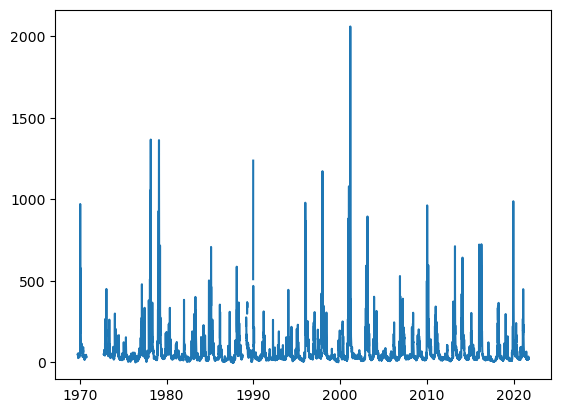

In [4]:
plt.plot(Q_Pis["Date"], Q_Pis["Q"])

In [5]:
Q_P = Q_Pis.to_xarray()
Q_P.to_netcdf("Data/Q_P.nc")

In [6]:
Q_P = Q_P.set_index()

In [2]:
def import_Q(dataloc, storeloc):
    df = pd.read_csv(
    dataloc,
    sep=";",
    skipinitialspace=True,
    na_values=["-999.000", "-999"],
    skiprows=36,
    encoding="latin-1"
    )
    df.describe()
    Q = df.drop(columns=df.columns[1])
    Q.columns = ["Date", "Q"]
    Q["Date"] = pd.to_datetime(Q["Date"])
    plt.plot(Q["Date"], Q["Q"])
    Q_X = Q.to_xarray()
    Q_X.to_netcdf(storeloc, mode='w')
    # Q_P = Q_P.set_index()
    return Q

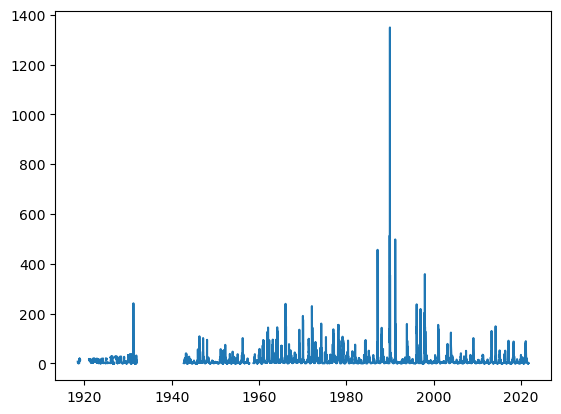

In [8]:
Q_Adaja = import_Q("Data/Q_Adaja.txt", "Data/Q_A.nc")

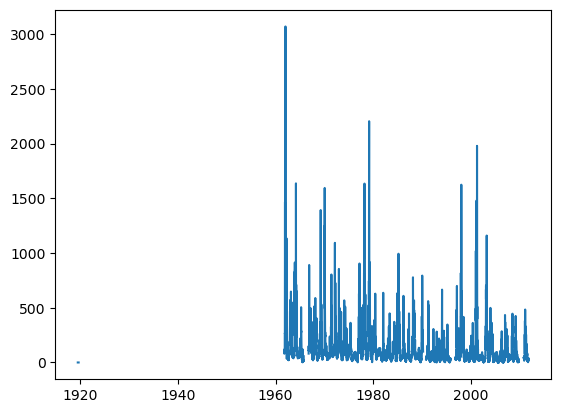

In [3]:
Q_Down = import_Q("Data/Q_down.txt", "Data/Q_down.nc")

In [1]:
Q_Down = import_Q("Data/Q_Toro.txt", "Data/Q_down.nc")

NameError: name 'import_Q' is not defined

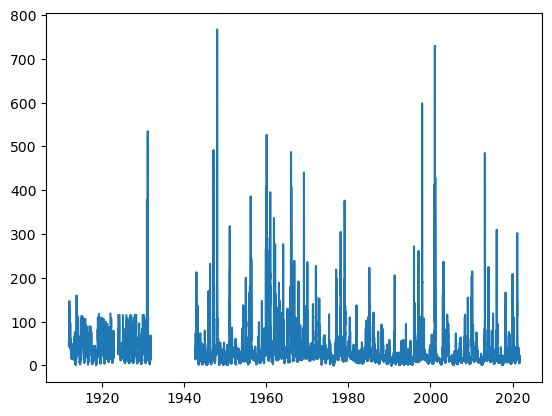

In [10]:
Q_D = import_Q("Data/Q_D.txt", "Data/Q_D.nc")

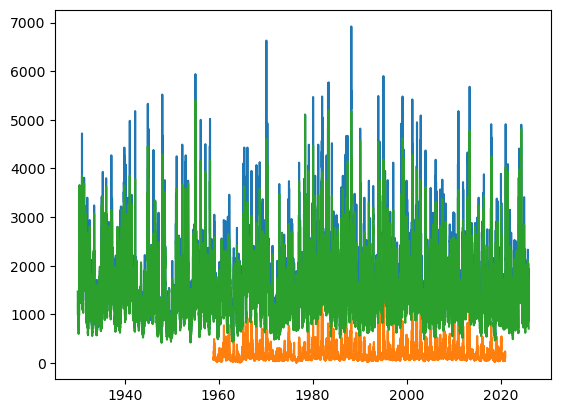

In [4]:
for i, name in enumerate(["Q_Down_Mainz.txt", "Q_KHB.txt", "Q_Worms.txt"]):
    import_Q(f"Data/{name}", f"Data/Discharges/Q_Rijn_{i}.nc")

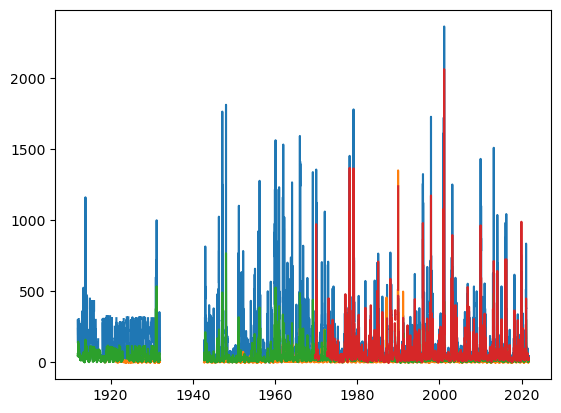

In [4]:
for i, name in enumerate(["Q_Toro.txt", "Q_Adaja.txt", "Q_D.txt", "Q_Pisuerga.txt"]):
    import_Q(f"Data/{name}", f"Data/Discharges/Q_Duero_{i}.nc")

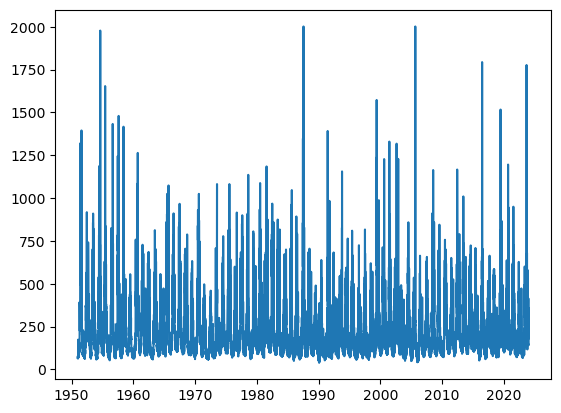

In [3]:
Q_Lust = import_Q("Data/Q_Lust.txt", "Data/Discharges/Q_Lust.nc")